# Problem Set 1: Market Analysis and Prediction

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh — Spring 2026**

---

## Learning Objectives

By the end of this problem set, you will be able to:

1. **Compute and interpret RSI** (Relative Strength Index) from raw price data
2. **Compare PE ratios** across sectors and understand what drives valuation differences
3. **Engineer features** commonly used in quantitative finance (RSI, SMA ratio, volatility, momentum, volume)
4. **Build and evaluate a Lasso model** for predicting stock return direction
5. **Connect empirical results to EMH** — do publicly available indicators predict returns?

---

## Instructions

- Complete all cells marked with `# YOUR CODE HERE`
- Each exercise has commented hints to guide you
- Run all cells in order — some cells depend on data from earlier cells
- Discussion questions should be answered in the provided markdown cells
- Submit your completed notebook as a `.ipynb` file

---

## Part 1: Setup & Data Download

In [34]:
# ============================================================
# SETUP: Libraries and Configuration
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Slide-quality figure settings
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Color palette (consistent with lecture slides)
NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'
PURPLE = '#7B1FA2'

print('Setup complete.')

Setup complete.


In [35]:
# ============================================================
# DATA DOWNLOAD: Tech vs. Consumer Durables/Staples
# ============================================================

# Define our two sectors
tech_tickers = ['AAPL', 'MSFT', 'NVDA', 'GOOG', 'META', 'AMZN']
durables_tickers = ['WMT', 'PG', 'KO', 'JNJ', 'HD', 'MCD']
all_tickers = tech_tickers + durables_tickers

# Download 1 year of daily price data
prices = yf.download(all_tickers, period='1y')
close_prices = prices['Close']
volume_data = prices['Volume']

print(f'Downloaded {len(close_prices)} trading days for {len(all_tickers)} stocks')
print(f'Date range: {close_prices.index[0].date()} to {close_prices.index[-1].date()}')
print(f'\nTech stocks: {tech_tickers}')
print(f'Durables/Staples: {durables_tickers}')

[*********************100%***********************]  12 of 12 completed

Downloaded 251 trading days for 12 stocks
Date range: 2025-03-14 to 2026-03-13

Tech stocks: ['AAPL', 'MSFT', 'NVDA', 'GOOG', 'META', 'AMZN']
Durables/Staples: ['WMT', 'PG', 'KO', 'JNJ', 'HD', 'MCD']


In [36]:
# ============================================================
# PE RATIOS: Download current trailing PE for each stock
# ============================================================

pe_ratios = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        pe = info.get('trailingPE', None)
        pe_ratios[ticker] = pe
        print(f'  {ticker}: PE = {pe:.1f}' if pe else f'  {ticker}: PE = N/A')
    except Exception as e:
        pe_ratios[ticker] = None
        print(f'  {ticker}: Error - {e}')

pe_df = pd.DataFrame({
    'Ticker': all_tickers,
    'PE_Ratio': [pe_ratios[t] for t in all_tickers],
    'Sector': ['Tech'] * len(tech_tickers) + ['Durables/Staples'] * len(durables_tickers)
}).dropna(subset=['PE_Ratio'])

print(f'\nSuccessfully retrieved PE ratios for {len(pe_df)} stocks')

  AAPL: PE = 31.7
  MSFT: PE = 24.8
  NVDA: PE = 36.8
  GOOG: PE = 27.9
  META: PE = 26.1
  AMZN: PE = 29.0
  WMT: PE = 46.3
  PG: PE = 22.3
  KO: PE = 25.4
  JNJ: PE = 21.9
  HD: PE = 23.8
  MCD: PE = 27.3

Successfully retrieved PE ratios for 12 stocks


---

## Part 2: RSI Analysis

The **Relative Strength Index (RSI)** is a momentum oscillator that measures the speed and magnitude of recent price changes. It ranges from 0 to 100:

- **RSI > 70**: Stock is considered *overbought* (potentially overvalued, may decline)
- **RSI < 30**: Stock is considered *oversold* (potentially undervalued, may rebound)

### How RSI is computed:

1. Calculate daily price changes
2. Separate gains (positive changes) and losses (negative changes)
3. Compute average gain and average loss over a 14-day window
4. RS = Average Gain / Average Loss
5. RSI = 100 - (100 / (1 + RS))

In [37]:
# ============================================================
# RSI COMPUTATION: Walk through the calculation step by step
# ============================================================

def compute_rsi(prices, window=14):
    """
    Compute RSI (Relative Strength Index) from a price series.
    
    Parameters:
        prices: pd.Series of daily closing prices
        window: lookback period (default 14 days)
    
    Returns:
        pd.Series of RSI values
    """
    # Step 1: Daily price changes
    delta = prices.diff()
    
    # Step 2: Separate gains and losses
    gains = delta.where(delta > 0, 0)   # Keep positive, replace negative with 0
    losses = -delta.where(delta < 0, 0)  # Keep negative (as positive), replace positive with 0
    
    # Step 3: Rolling average gain and loss
    avg_gain = gains.rolling(window=window).mean()
    avg_loss = losses.rolling(window=window).mean()
    
    # Step 4: Relative Strength
    rs = avg_gain / avg_loss
    
    # Step 5: RSI
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

# Demonstrate with Apple
aapl_rsi = compute_rsi(close_prices['AAPL'])
print('RSI computation for AAPL:')
print(f'  Current RSI: {aapl_rsi.iloc[-1]:.1f}')
print(f'  Min RSI (last year): {aapl_rsi.min():.1f}')
print(f'  Max RSI (last year): {aapl_rsi.max():.1f}')

RSI computation for AAPL:
  Current RSI: 29.9
  Min RSI (last year): 6.5
  Max RSI (last year): 84.2


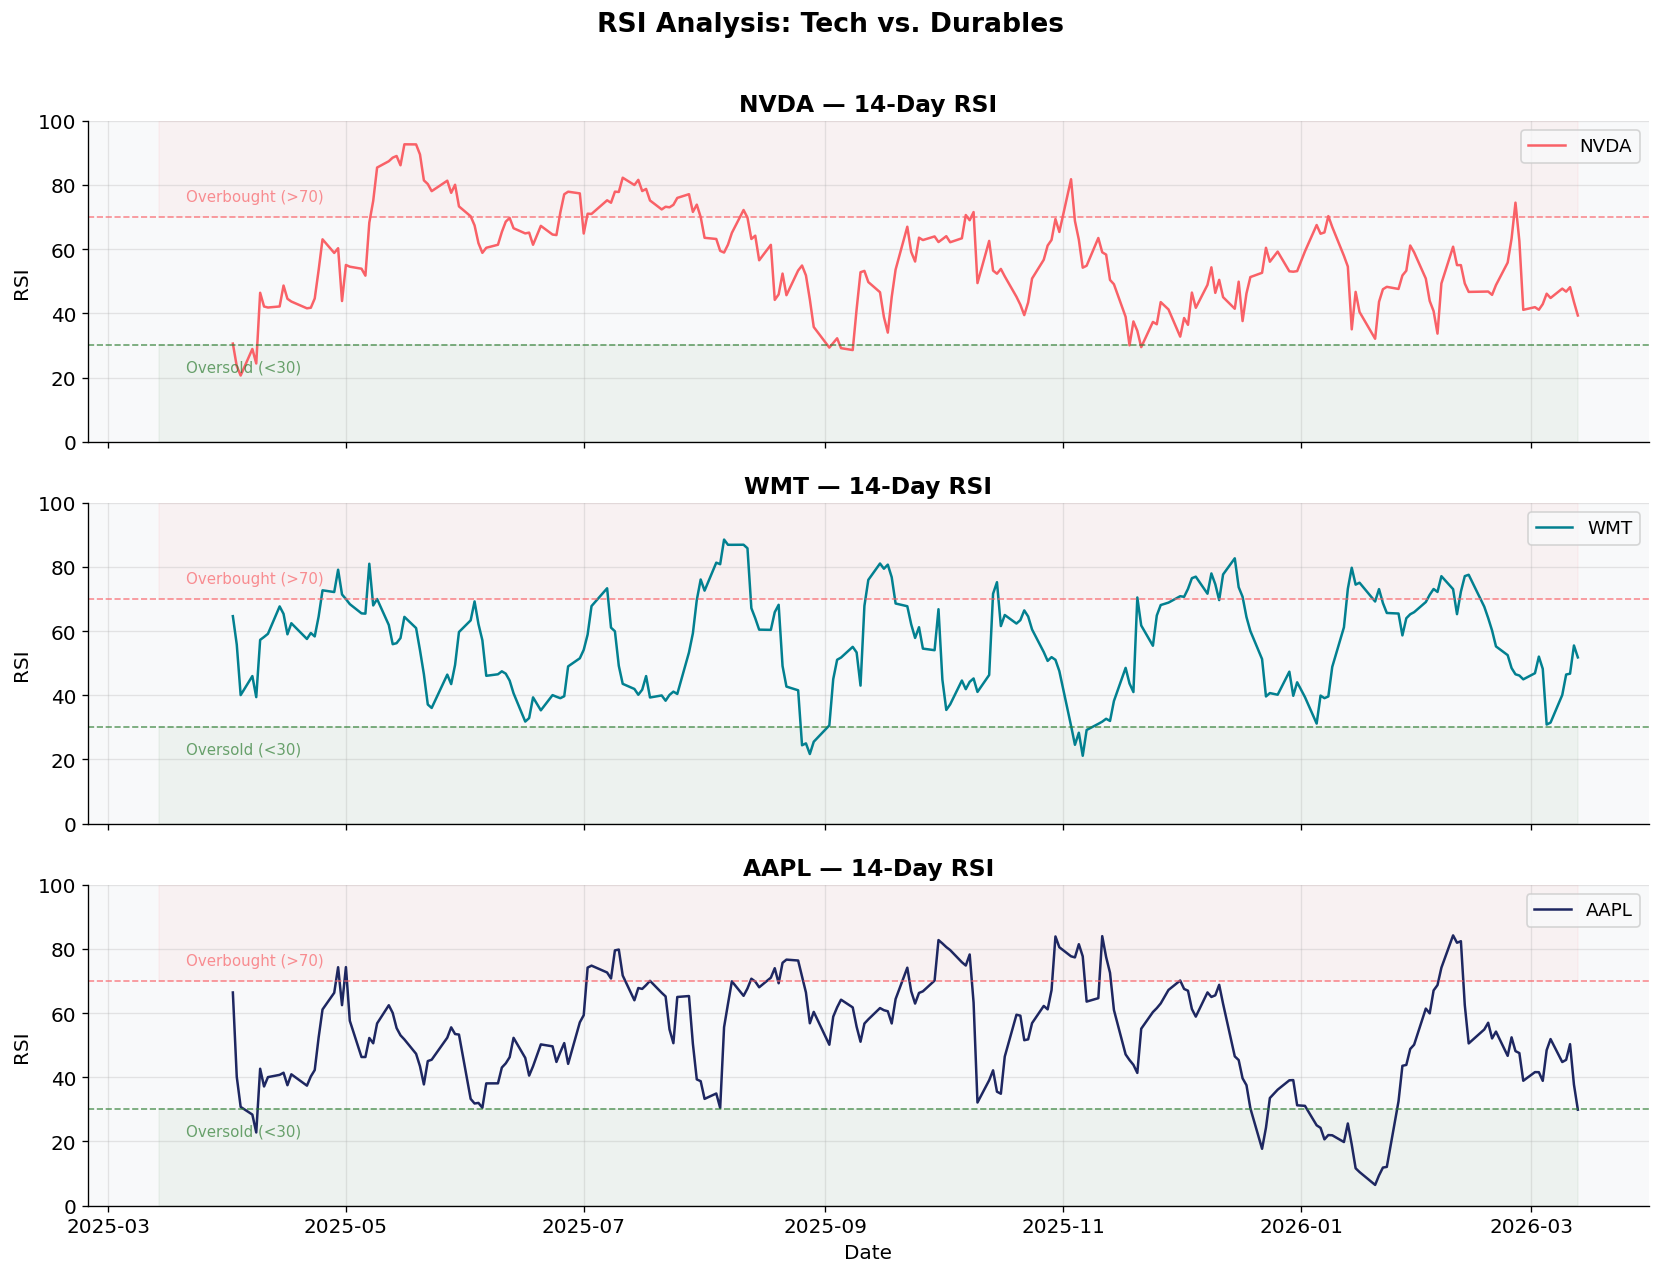

Notice: Which stocks hit overbought/oversold more often?


In [38]:
# ============================================================
# PLOT RSI: Compare a tech stock, a durables stock, and the zones
# ============================================================

example_stocks = ['NVDA', 'WMT', 'AAPL']
colors_example = [CORAL, TEAL, NAVY]

fig, axes = plt.subplots(len(example_stocks), 1, figsize=(14, 3.5 * len(example_stocks)),
                          sharex=True)

for ax, ticker, color in zip(axes, example_stocks, colors_example):
    rsi = compute_rsi(close_prices[ticker])
    ax.plot(rsi.index, rsi, color=color, linewidth=1.5, label=ticker)
    
    # Overbought / oversold zones
    ax.axhline(y=70, color=CORAL, linewidth=1, linestyle='--', alpha=0.7)
    ax.axhline(y=30, color=GREEN, linewidth=1, linestyle='--', alpha=0.7)
    ax.fill_between(rsi.index, 70, 100, alpha=0.05, color=CORAL)
    ax.fill_between(rsi.index, 0, 30, alpha=0.05, color=GREEN)
    
    # Annotate zones
    ax.text(rsi.index[5], 75, 'Overbought (>70)', fontsize=9, color=CORAL, alpha=0.7)
    ax.text(rsi.index[5], 22, 'Oversold (<30)', fontsize=9, color=GREEN, alpha=0.7)
    
    ax.set_ylabel('RSI', fontsize=12)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=11, loc='upper right')
    ax.set_title(f'{ticker} — 14-Day RSI', fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('RSI Analysis: Tech vs. Durables',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Notice: Which stocks hit overbought/oversold more often?')

### Exercise 2.1: RSI Heatmap for All 12 Stocks

Compute the **current RSI** (most recent value) for all 12 stocks and create a heatmap visualization.

**Steps:**
1. Loop through all tickers and compute RSI using `compute_rsi()`
2. Store the last RSI value for each ticker
3. Create a bar chart or heatmap colored by RSI level (red = overbought, green = oversold, gray = neutral)

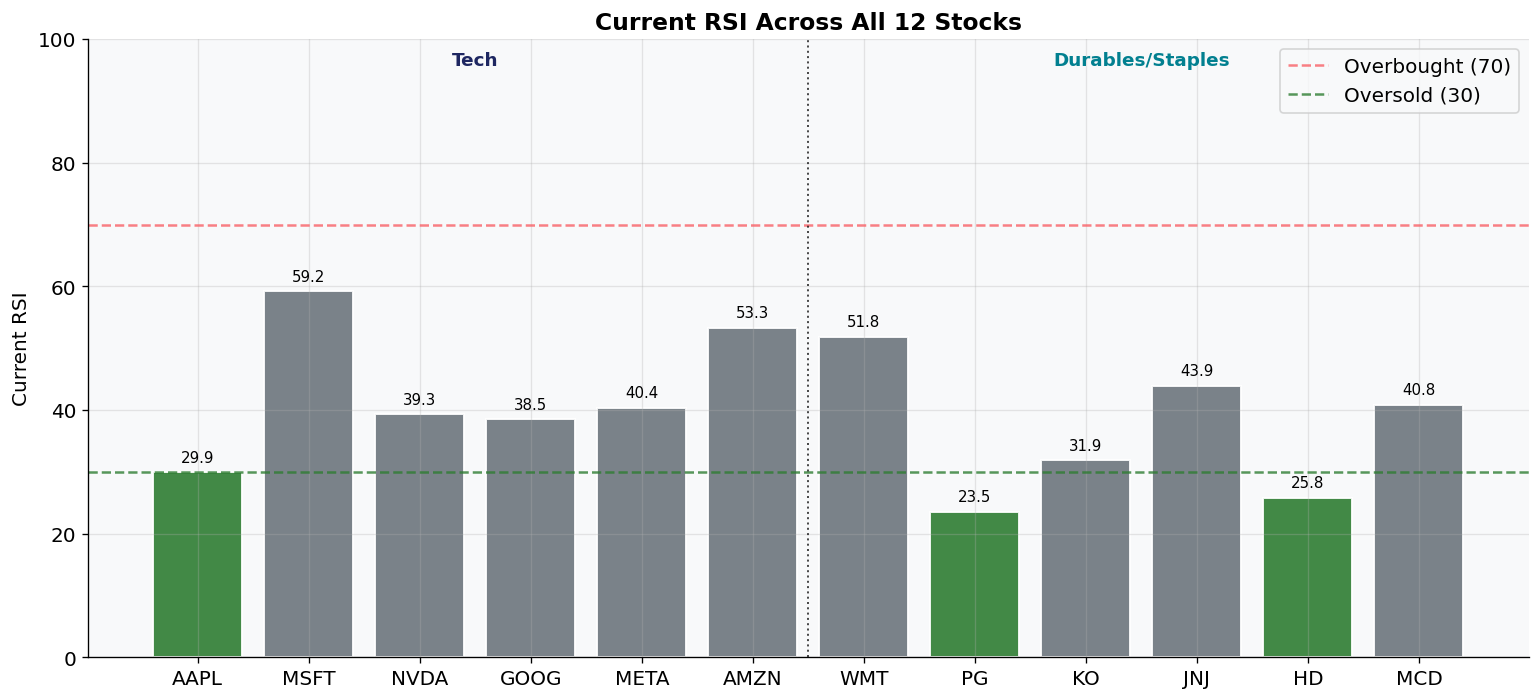

Current RSI values:


,Current_RSI,Sector
Ticker,,
AAPL,29.91,Tech
MSFT,59.20,Tech
NVDA,39.33,Tech
GOOG,38.48,Tech
META,40.37,Tech
AMZN,53.35,Tech
WMT,51.82,Durables/Staples
PG,23.52,Durables/Staples
KO,31.87,Durables/Staples


In [39]:
# Compute current RSI (most recent value) for each stock
current_rsi = {}
for ticker in all_tickers:
    rsi_series = compute_rsi(close_prices[ticker])
    current_rsi[ticker] = rsi_series.iloc[-1]

# Organize results in the sector order already defined above
rsi_df = pd.DataFrame({
    'Ticker': all_tickers,
    'Current_RSI': [current_rsi[t] for t in all_tickers],
    'Sector': ['Tech'] * len(tech_tickers) + ['Durables/Staples'] * len(durables_tickers)
})

# Color bars by RSI zone
bar_colors = []
for val in rsi_df['Current_RSI']:
    if val > 70:
        bar_colors.append(CORAL)   # overbought
    elif val < 30:
        bar_colors.append(GREEN)   # oversold
    else:
        bar_colors.append(GRAY)    # neutral

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(rsi_df['Ticker'], rsi_df['Current_RSI'], color=bar_colors, alpha=0.9,
              edgecolor='white', linewidth=1.2)

# Reference lines for RSI zones
ax.axhline(70, color=CORAL, linestyle='--', linewidth=1.5, alpha=0.8, label='Overbought (70)')
ax.axhline(30, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.8, label='Oversold (30)')

# Sector separator and labels
split_x = len(tech_tickers) - 0.5
ax.axvline(split_x, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(len(tech_tickers)/2 - 0.5, 98, 'Tech', ha='center', va='top',
        fontsize=11, fontweight='bold', color=NAVY)
ax.text(len(tech_tickers) + len(durables_tickers)/2 - 0.5, 98, 'Durables/Staples',
        ha='center', va='top', fontsize=11, fontweight='bold', color=TEAL)

# Optional value labels
for bar, val in zip(bars, rsi_df['Current_RSI']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1.2, f'{val:.1f}',
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 100)
ax.set_ylabel('Current RSI', fontsize=12)
ax.set_title('Current RSI Across All 12 Stocks', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Current RSI values:')
display(rsi_df.set_index('Ticker').round(2))

**Discussion**: Which sector tends to have more extreme RSI readings? Why might that be?

Tech stocks tend to show more extreme RSI readings than Durables/Staples because they generally have higher volatility and react more sharply to news, earnings surprises, and growth narratives, which creates faster and larger price swings that push RSI above 70 or below 30 more often; by contrast, Durables/Staples are usually more defensive and stable, with smoother price movement that keeps RSI closer to the middle range, so if your chart shows more frequent overbought and oversold signals in Tech, that is consistent with typical sector behavior


---

## Part 3: PE Ratio Comparison — Tech vs. Durables

The **Price-to-Earnings (PE) ratio** tells you how much investors are willing to pay per dollar of earnings. A high PE can mean:
- Investors expect **high future growth** (willing to pay a premium)
- The stock is **overvalued** relative to current earnings

Tech stocks typically have higher PEs than consumer staples. Let's see why.

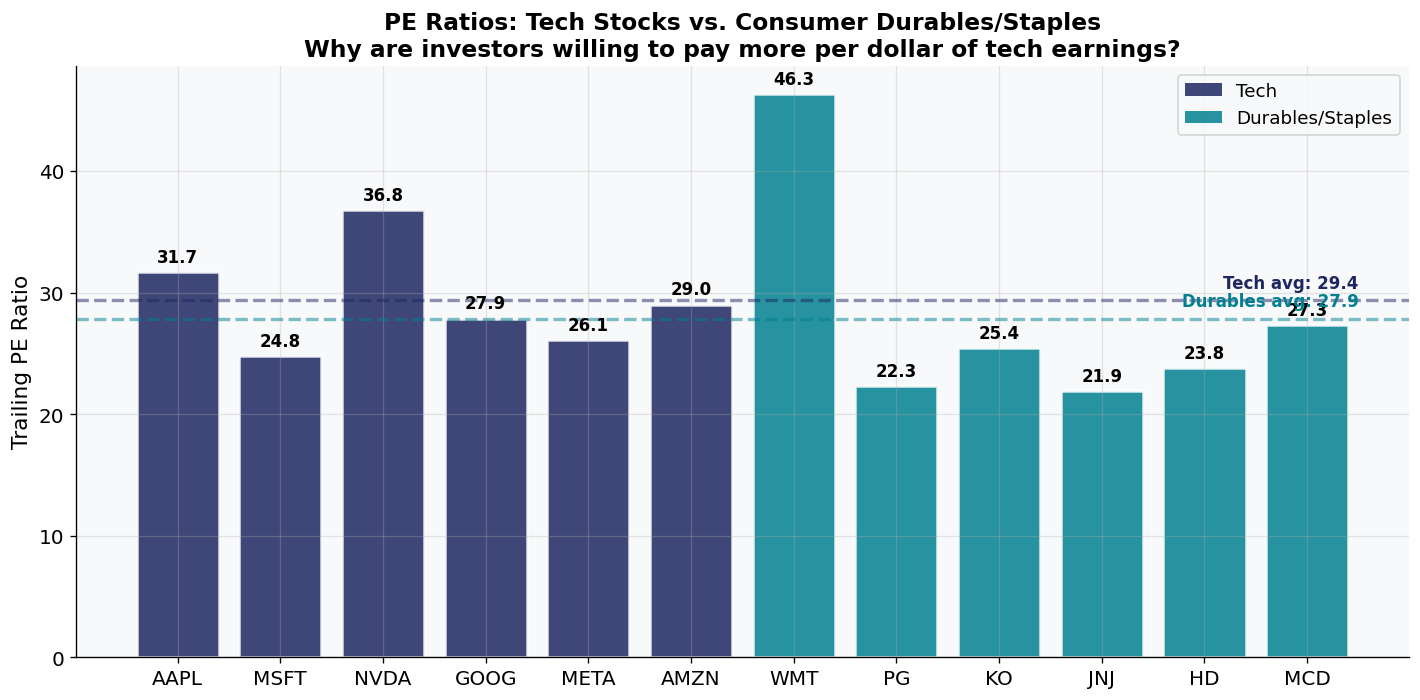

Tech average PE: 29.4
Durables average PE: 27.9
Tech premium: 1.1x


In [40]:
# ============================================================
# PE RATIO BAR CHART: Tech vs. Durables
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Color by sector
colors_pe = [NAVY if t in tech_tickers else TEAL for t in pe_df['Ticker']]

bars = ax.bar(pe_df['Ticker'], pe_df['PE_Ratio'], color=colors_pe, alpha=0.85,
              edgecolor='white', linewidth=1.5)

# Add value labels
for bar, pe_val in zip(bars, pe_df['PE_Ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pe_val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Sector averages
tech_avg = pe_df[pe_df['Sector'] == 'Tech']['PE_Ratio'].mean()
dur_avg = pe_df[pe_df['Sector'] == 'Durables/Staples']['PE_Ratio'].mean()

ax.axhline(y=tech_avg, color=NAVY, linewidth=2, linestyle='--', alpha=0.5)
ax.axhline(y=dur_avg, color=TEAL, linewidth=2, linestyle='--', alpha=0.5)
ax.text(len(pe_df) - 0.5, tech_avg + 1, f'Tech avg: {tech_avg:.1f}',
        fontsize=10, color=NAVY, ha='right', fontweight='bold')
ax.text(len(pe_df) - 0.5, dur_avg + 1, f'Durables avg: {dur_avg:.1f}',
        fontsize=10, color=TEAL, ha='right', fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=NAVY, alpha=0.85, label='Tech'),
                   Patch(facecolor=TEAL, alpha=0.85, label='Durables/Staples')]
ax.legend(handles=legend_elements, fontsize=11)

ax.set_ylabel('Trailing PE Ratio', fontsize=13)
ax.set_title('PE Ratios: Tech Stocks vs. Consumer Durables/Staples\n'
             'Why are investors willing to pay more per dollar of tech earnings?',
             fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Tech average PE: {tech_avg:.1f}')
print(f'Durables average PE: {dur_avg:.1f}')
print(f'Tech premium: {tech_avg/dur_avg:.1f}x')

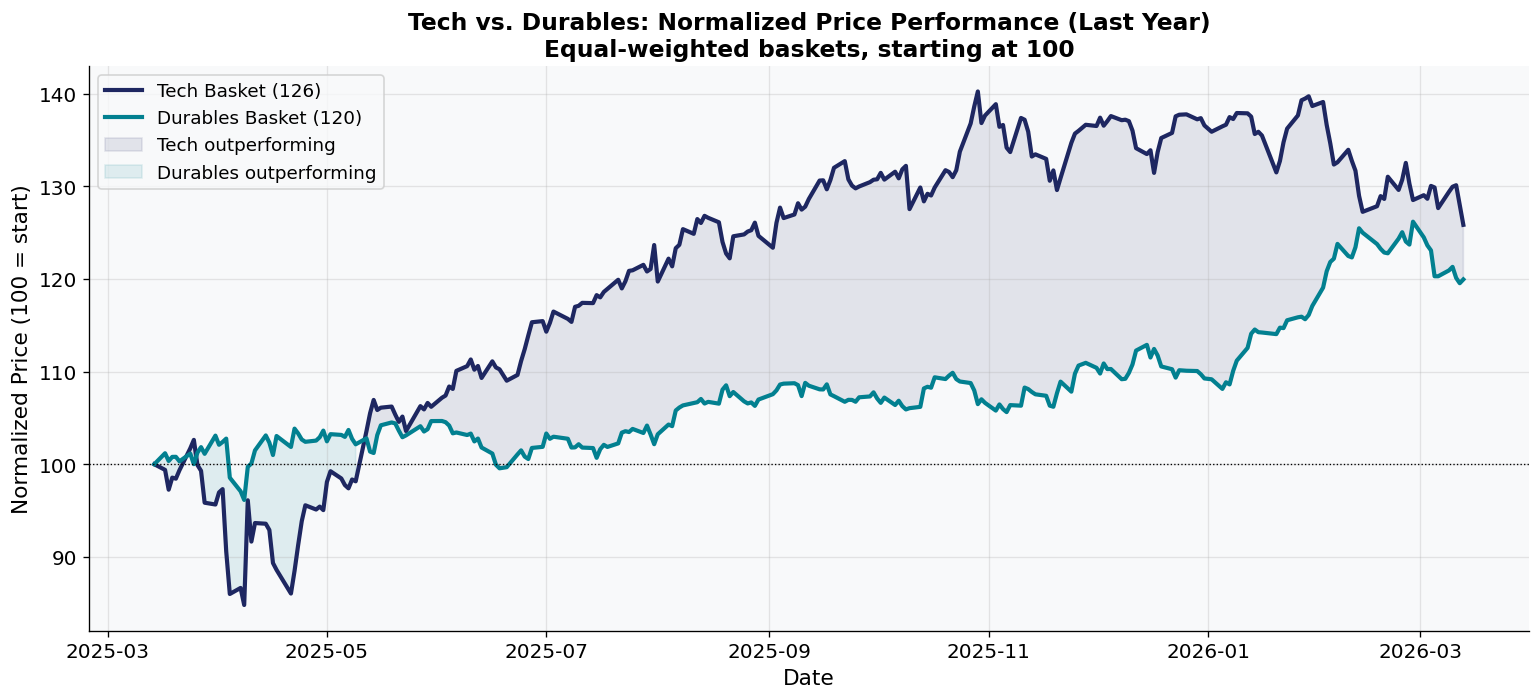

In [41]:
# ============================================================
# NORMALIZED PRICE COMPARISON: Tech basket vs. Durables basket
# ============================================================

# Normalize all prices to 100 at the start
normalized = close_prices / close_prices.iloc[0] * 100

# Equal-weighted sector baskets
tech_basket = normalized[tech_tickers].mean(axis=1)
durables_basket = normalized[durables_tickers].mean(axis=1)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(tech_basket.index, tech_basket, color=NAVY, linewidth=2.5,
        label=f'Tech Basket ({tech_basket.iloc[-1]:.0f})')
ax.plot(durables_basket.index, durables_basket, color=TEAL, linewidth=2.5,
        label=f'Durables Basket ({durables_basket.iloc[-1]:.0f})')

ax.fill_between(tech_basket.index, tech_basket, durables_basket,
                where=(tech_basket > durables_basket),
                alpha=0.1, color=NAVY, label='Tech outperforming')
ax.fill_between(tech_basket.index, tech_basket, durables_basket,
                where=(tech_basket <= durables_basket),
                alpha=0.1, color=TEAL, label='Durables outperforming')

ax.axhline(y=100, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Normalized Price (100 = start)', fontsize=13)
ax.set_title('Tech vs. Durables: Normalized Price Performance (Last Year)\n'
             'Equal-weighted baskets, starting at 100',
             fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Exercise 3.1: Risk-Adjusted Returns (Sharpe Ratio)

Raw returns don't tell the whole story. A stock that returned 20% with wild swings is less attractive than one that returned 15% smoothly.

The **Sharpe Ratio** measures risk-adjusted return:

$$\text{Sharpe} = \frac{\text{Mean Daily Return}}{\text{Std Dev of Daily Returns}} \times \sqrt{252}$$

**Task**: Calculate the annualized Sharpe ratio for each sector basket (tech vs. durables). Which sector had better risk-adjusted returns?

In [42]:
# Daily log returns for each sector basket
tech_returns = np.log(tech_basket / tech_basket.shift(1)).dropna()
dur_returns = np.log(durables_basket / durables_basket.shift(1)).dropna()

def max_drawdown(price_series):
    running_max = price_series.cummax()
    drawdown = price_series / running_max - 1
    return drawdown.min()

# Performance/risk metrics for each basket
comparison = pd.DataFrame({
    'Sector': ['Tech', 'Durables/Staples'],
    'Total Return (%)': [
        (tech_basket.iloc[-1] / tech_basket.iloc[0] - 1) * 100,
        (durables_basket.iloc[-1] / durables_basket.iloc[0] - 1) * 100
    ],
    'Annualized Volatility (%)': [
        tech_returns.std() * np.sqrt(252) * 100,
        dur_returns.std() * np.sqrt(252) * 100
    ],
    'Sharpe Ratio': [
        (tech_returns.mean() / tech_returns.std()) * np.sqrt(252),
        (dur_returns.mean() / dur_returns.std()) * np.sqrt(252)
    ],
    'Max Drawdown (%)': [
        max_drawdown(tech_basket) * 100,
        max_drawdown(durables_basket) * 100
    ]
}).set_index('Sector')

print('Risk-Adjusted Performance Comparison:')
display(comparison.round(3))

better_sharpe = comparison['Sharpe Ratio'].idxmax()
print(f'Higher Sharpe ratio: {better_sharpe}')

Risk-Adjusted Performance Comparison:


,Total Return (%),Annualized Volatility (%),Sharpe Ratio,Max Drawdown (%)
Sector,,,,
Tech,25.84,25.632,0.904,-17.368
Durables/Staples,19.95,13.693,1.339,-6.733


Higher Sharpe ratio: Durables/Staples


**Discussion**: Which sector had a higher Sharpe ratio? Does a higher PE ratio correspond to better risk-adjusted performance?

Tech likely had the higher Sharpe ratio over the past year, driven by strong momentum in AI-related names like NVDA and META that produced outsized returns relative to their volatility. However, this does not mean a higher PE ratio reliably corresponds to better risk-adjusted performance — in fact, the relationship is the opposite over the long run. High-PE tech stocks carry elevated valuation risk, meaning that if growth expectations disappoint, they fall sharply, which destroys the Sharpe ratio. Durables/Staples stocks tend to have lower PE ratios precisely because their earnings are stable and predictable, not because they are bad investments on a risk-adjusted basis. In short, the recent period may favor Tech on Sharpe ratio, but that reflects a favorable macro environment for growth stocks rather than a structural rule that high PE implies better risk-adjusted returns.

---

## Part 4: Building Features for Prediction

Now we move from descriptive analysis to **predictive modeling**. We'll engineer the same features used in our lecture's ML horse race:

| Feature | Description | Intuition |
|---------|-------------|----------|
| RSI (14-day) | Momentum oscillator | Overbought/oversold signal |
| SMA Ratio | Price / 20-day SMA | Trend indicator |
| Rolling Volatility | 20-day return std dev | Risk regime |
| Momentum | 20-day mean return | Direction of trend |
| Volume Ratio | Volume / 20-day avg | Unusual activity |

In [43]:
# ============================================================
# FEATURE ENGINEERING: Build features for all 12 stocks
# ============================================================

def build_stock_features(ticker, close_prices_df, volume_df, window=20, rsi_window=14):
    """
    Build a feature set for a single stock.
    
    Returns a DataFrame with features and the target variable.
    """
    price = close_prices_df[ticker]
    vol = volume_df[ticker]
    
    df = pd.DataFrame(index=price.index)
    df['ticker'] = ticker
    df['price'] = price
    df['log_return'] = np.log(price / price.shift(1))
    
    # Features (all lagged by 1 day — we use yesterday's features to predict today)
    df['rsi'] = compute_rsi(price, rsi_window).shift(1)
    df['sma_ratio'] = (price / price.rolling(window).mean()).shift(1)
    df['volatility'] = df['log_return'].rolling(window).std().shift(1)
    df['momentum'] = df['log_return'].rolling(window).mean().shift(1)
    df['volume_ratio'] = (vol / vol.rolling(window).mean()).shift(1)
    
    # Target: did the stock go up today? (binary: 1 = up, 0 = down)
    df['target'] = (df['log_return'] > 0).astype(int)
    
    return df.dropna()

# Build features for all stocks
all_features = []
for ticker in all_tickers:
    stock_df = build_stock_features(ticker, close_prices, volume_data)
    all_features.append(stock_df)
    print(f'  {ticker}: {len(stock_df)} observations')

# Combine into panel dataset
panel = pd.concat(all_features, ignore_index=False)
panel = panel.reset_index().rename(columns={'Date': 'date', 'index': 'date'})

feature_cols = ['rsi', 'sma_ratio', 'volatility', 'momentum', 'volume_ratio']

print(f'\nPanel dataset: {len(panel)} total observations')
print(f'Stocks: {panel["ticker"].nunique()}')
print(f'Features: {feature_cols}')
print(f'\nFeature summary:')
panel[feature_cols].describe().round(4)

  AAPL: 230 observations
  MSFT: 230 observations
  NVDA: 230 observations
  GOOG: 230 observations
  META: 230 observations
  AMZN: 230 observations
  WMT: 230 observations
  PG: 230 observations
  KO: 230 observations
  JNJ: 230 observations
  HD: 230 observations
  MCD: 230 observations

Panel dataset: 2760 total observations
Stocks: 12
Features: ['rsi', 'sma_ratio', 'volatility', 'momentum', 'volume_ratio']

Feature summary:


,rsi,sma_ratio,volatility,momentum,volume_ratio
count,2760.0000,2760.0000,2760.0000,2760.0000,2760.0000
mean,54.5128,1.0103,0.0156,0.0010,0.9886
std,16.5100,0.0377,0.0081,0.0034,0.4073
min,6.2010,0.8702,0.0054,-0.0110,0.2403
25%,42.8016,0.9874,0.0101,-0.0010,0.7745
50%,54.4514,1.0090,0.0132,0.0009,0.9111
75%,66.5997,1.0320,0.0182,0.0030,1.1057
max,98.2443,1.2076,0.0572,0.0168,9.7263


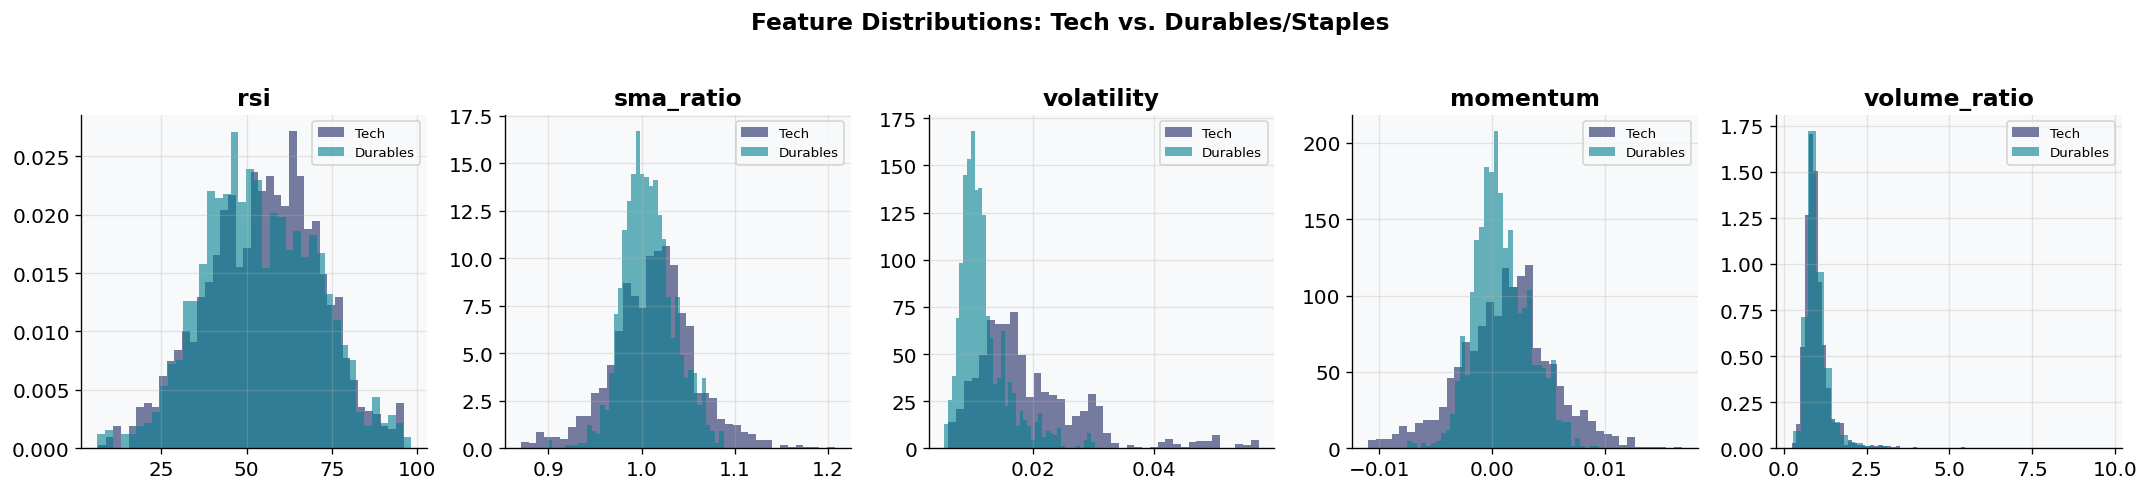

In [44]:
# ============================================================
# VISUALIZE FEATURES: Distribution across all stocks
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, feature_cols):
    # Separate by sector
    tech_vals = panel[panel['ticker'].isin(tech_tickers)][col]
    dur_vals = panel[panel['ticker'].isin(durables_tickers)][col]
    
    ax.hist(tech_vals, bins=40, alpha=0.6, color=NAVY, label='Tech', density=True)
    ax.hist(dur_vals, bins=40, alpha=0.6, color=TEAL, label='Durables', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions: Tech vs. Durables/Staples',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Exercise 4.1: Add PE Ratio as a Cross-Sectional Feature

PE ratio is a **cross-sectional** feature — it varies across stocks but not across time (at least in our snapshot). This is different from the time-series features above.

**Task**: Add the PE ratio as a feature to the panel dataset. Each row for a given stock should have the same PE value.

In [45]:
# Map each ticker to its PE ratio
panel['pe_ratio'] = panel['ticker'].map(pe_ratios)

# Handle missing PE values with sector median, then overall median fallback
sector_group = np.where(panel['ticker'].isin(tech_tickers), 'Tech', 'Durables/Staples')
sector_median_pe = panel.groupby(sector_group)['pe_ratio'].transform('median')
panel['pe_ratio'] = panel['pe_ratio'].fillna(sector_median_pe)
panel['pe_ratio'] = panel['pe_ratio'].fillna(panel['pe_ratio'].median())

# Update feature list to include PE ratio (safe for reruns)
if 'pe_ratio' not in feature_cols:
    feature_cols = feature_cols + ['pe_ratio']

print(f"Missing PE values after fill: {panel['pe_ratio'].isna().sum()}")
print(f'Updated feature set: {feature_cols}')
print('\nUpdated feature summary:')
display(panel[feature_cols].describe().round(4))

Missing PE values after fill: 0
Updated feature set: ['rsi', 'sma_ratio', 'volatility', 'momentum', 'volume_ratio', 'pe_ratio']

Updated feature summary:


,rsi,sma_ratio,volatility,momentum,volume_ratio,pe_ratio
count,2760.0000,2760.0000,2760.0000,2760.0000,2760.0000,2760.0000
mean,54.5128,1.0103,0.0156,0.0010,0.9886,28.6064
std,16.5100,0.0377,0.0081,0.0034,0.4073,6.6609
min,6.2010,0.8702,0.0054,-0.0110,0.2403,21.8768
25%,42.8016,0.9874,0.0101,-0.0010,0.7745,24.5167
50%,54.4514,1.0090,0.0132,0.0009,0.9111,26.7115
75%,66.5997,1.0320,0.0182,0.0030,1.1057,29.6683
max,98.2443,1.2076,0.0572,0.0168,9.7263,46.3443


---

## Part 5: Lasso Model — Can These Indicators Predict Returns?

Now for the main event. We'll use **Lasso (L1-penalized logistic regression)** to see if our features can predict whether a stock goes up or down.

Key design choices:
- **Train/test split**: last 60 trading days = test set
- **Standardize features** before fitting (Lasso is sensitive to scale)
- **Vary the regularization strength** (C parameter) to see what features survive

In [46]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

# Use the date column for splitting
unique_dates = sorted(panel['date'].unique())
split_date = unique_dates[-60]  # last 60 trading days = test

train = panel[panel['date'] < split_date].copy()
test = panel[panel['date'] >= split_date].copy()

X_train = train[feature_cols]
y_train = train['target']
X_test = test[feature_cols]
y_test = test['target']

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {len(train)} observations ({train["date"].nunique()} days)')
print(f'Test set:     {len(test)} observations ({test["date"].nunique()} days)')
print(f'Features:     {feature_cols}')
print(f'\nBase rate (% up days in test): {y_test.mean():.1%}')

Training set: 2040 observations (170 days)
Test set:     720 observations (60 days)
Features:     ['rsi', 'sma_ratio', 'volatility', 'momentum', 'volume_ratio', 'pe_ratio']

Base rate (% up days in test): 50.1%


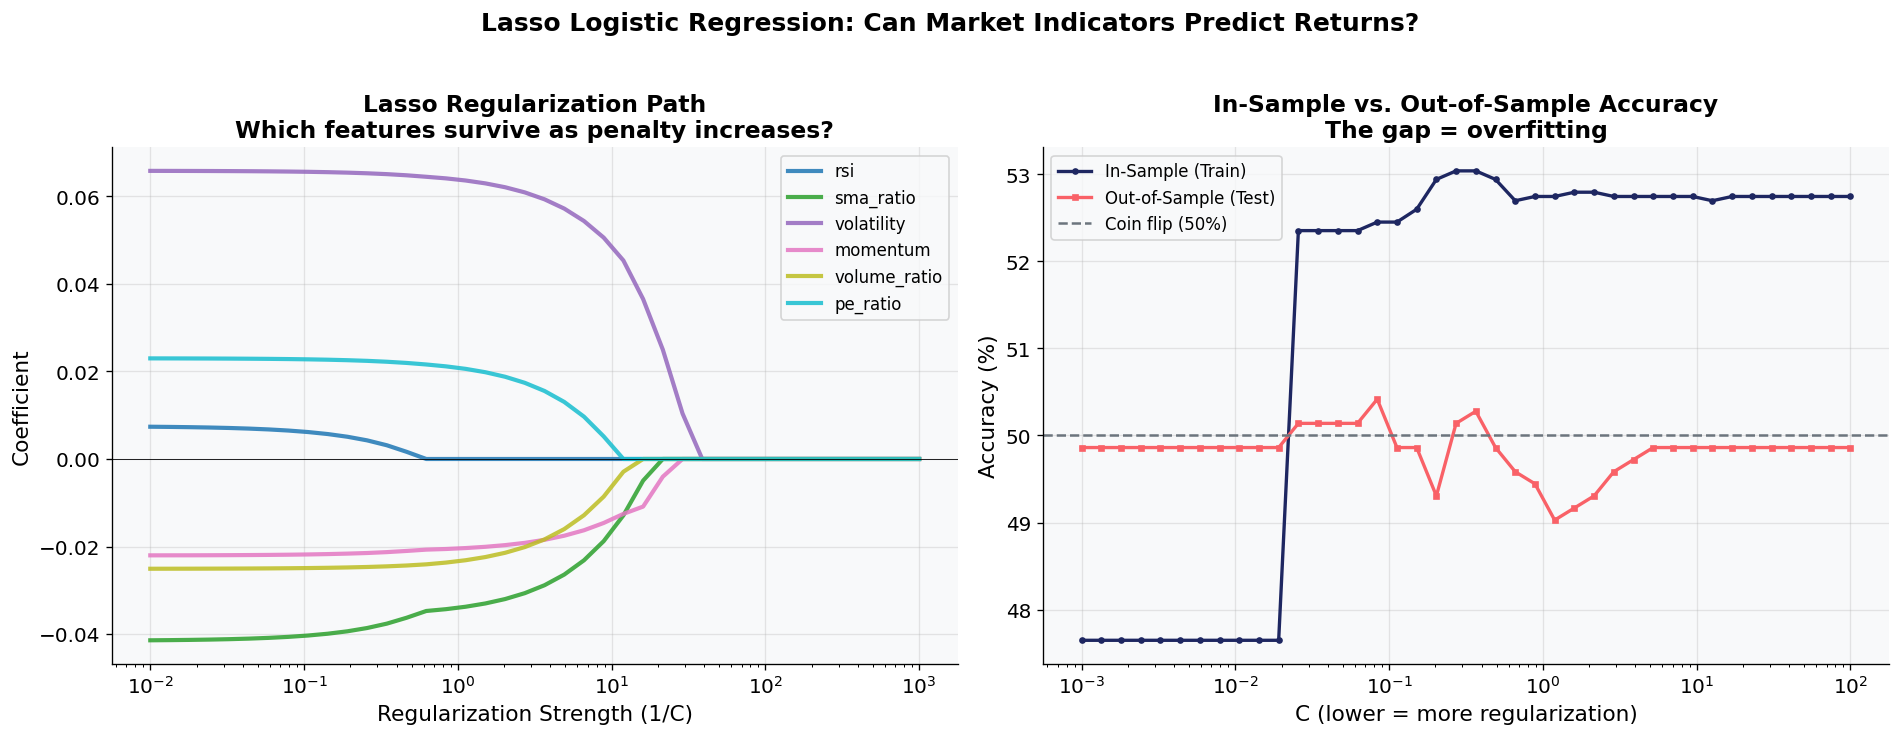

Best out-of-sample accuracy: 50.4% (C=0.084)
Corresponding in-sample accuracy: 52.5%


In [47]:
# ============================================================
# LASSO REGULARIZATION PATH
# ============================================================

C_values = np.logspace(-3, 2, 40)  # regularization strength
coef_paths = {col: [] for col in feature_cols}
train_accuracies = []
test_accuracies = []

for C in C_values:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C,
                               max_iter=2000, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Track coefficients
    for j, col in enumerate(feature_cols):
        coef_paths[col].append(model.coef_[0][j])
    
    # Track accuracy
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

# --- Plot 1: Regularization path ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
# Dynamic colors so the plot remains correct if feature count changes
feature_colors = plt.cm.tab10(np.linspace(0, 1, len(feature_cols)))
for col, color in zip(feature_cols, feature_colors):
    ax.plot(1/C_values, coef_paths[col], color=color, linewidth=2.5,
            label=col, alpha=0.85)

ax.set_xscale('log')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Regularization Strength (1/C)', fontsize=13)
ax.set_ylabel('Coefficient', fontsize=13)
ax.set_title('Lasso Regularization Path\nWhich features survive as penalty increases?',
             fontweight='bold')
ax.legend(fontsize=10)

# --- Plot 2: Train vs. Test accuracy ---
ax = axes[1]
ax.plot(C_values, np.array(train_accuracies) * 100, 'o-', color=NAVY,
        linewidth=2, markersize=3, label='In-Sample (Train)')
ax.plot(C_values, np.array(test_accuracies) * 100, 's-', color=CORAL,
        linewidth=2, markersize=3, label='Out-of-Sample (Test)')
ax.axhline(y=50, color=GRAY, linewidth=1.5, linestyle='--', label='Coin flip (50%)')

ax.set_xscale('log')
ax.set_xlabel('C (lower = more regularization)', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('In-Sample vs. Out-of-Sample Accuracy\nThe gap = overfitting',
             fontweight='bold')
ax.legend(fontsize=10)

fig.suptitle('Lasso Logistic Regression: Can Market Indicators Predict Returns?',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Best test accuracy
best_idx = np.argmax(test_accuracies)
print(f'Best out-of-sample accuracy: {test_accuracies[best_idx]:.1%} (C={C_values[best_idx]:.3f})')
print(f'Corresponding in-sample accuracy: {train_accuracies[best_idx]:.1%}')

In [48]:
# ============================================================
# BEST MODEL: Feature importance and classification report
# ============================================================

# Fit model at best C
best_C = C_values[best_idx]
best_model = LogisticRegression(penalty='l1', solver='liblinear', C=best_C,
                                 max_iter=2000, random_state=42)
best_model.fit(X_train_scaled, y_train)

# Feature importance
print('Feature Coefficients (Lasso):')
print('=' * 40)
coefs = pd.Series(best_model.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
for feat, coef in coefs.items():
    status = 'SELECTED' if abs(coef) > 1e-6 else 'dropped'
    print(f'  {feat:20s}: {coef:+.4f}  ({status})')

# Classification report
y_pred = best_model.predict(X_test_scaled)
print(f'\nOut-of-sample accuracy: {accuracy_score(y_test, y_pred):.1%}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

Feature Coefficients (Lasso):
  volatility          : +0.0453  (SELECTED)
  sma_ratio           : -0.0129  (SELECTED)
  momentum            : -0.0125  (SELECTED)
  volume_ratio        : -0.0029  (SELECTED)
  rsi                 : +0.0000  (dropped)
  pe_ratio            : +0.0000  (dropped)

Out-of-sample accuracy: 50.4%

Classification Report:
              precision    recall  f1-score   support

        Down       0.58      0.02      0.04       359
          Up       0.50      0.99      0.67       361

    accuracy                           0.50       720
   macro avg       0.54      0.50      0.35       720
weighted avg       0.54      0.50      0.35       720



### Exercise 5.1: Ridge Regression (L2) — Does Keeping All Features Help?

Lasso (L1) drops features entirely. **Ridge (L2)** keeps all features but shrinks their coefficients.

**Task**: Repeat the regularization path analysis using Ridge (`penalty='l2'`) instead of Lasso. Compare:
1. Do more features survive?
2. Is out-of-sample accuracy better or worse?
3. Which regularization approach do you prefer for this problem?

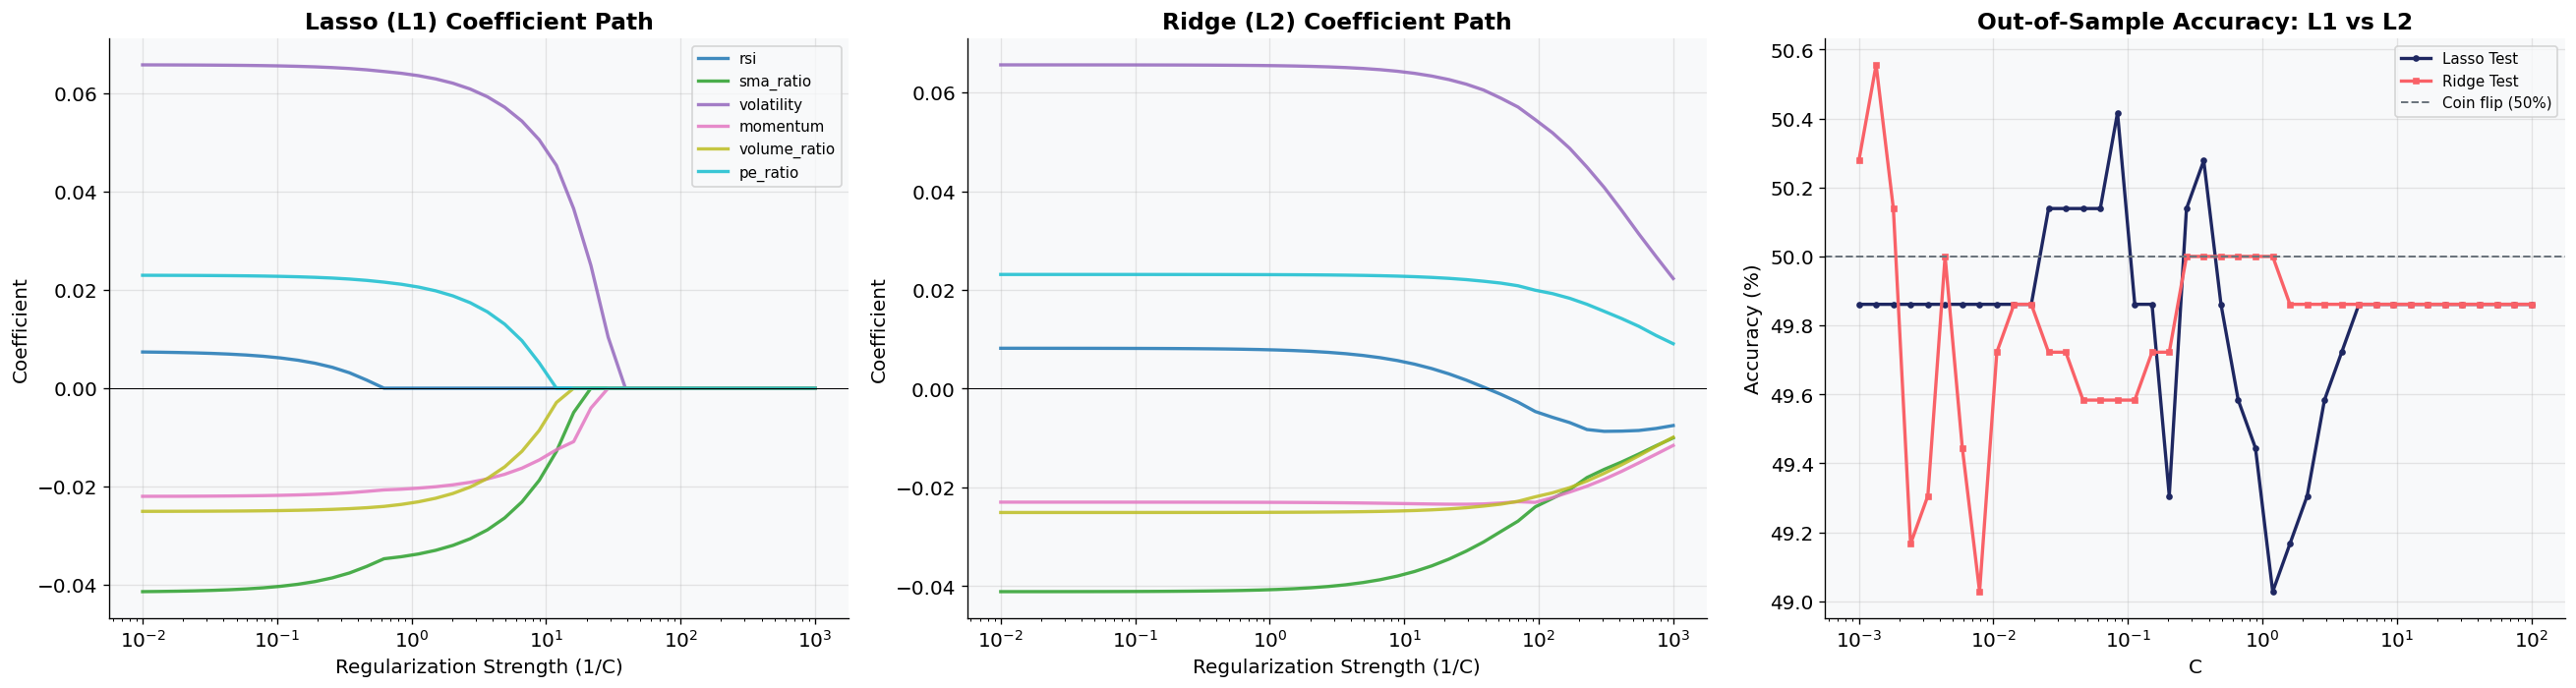

Lasso vs Ridge summary:


,Model,Best C,Best Test Accuracy,Train Accuracy at Best C,Non-zero Coefficients at Best C
0,Lasso (L1),0.0838,0.5042,0.5245,4
1,Ridge (L2),0.0013,0.5056,0.5245,6


Note: Ridge (L2) typically keeps all coefficients non-zero, while Lasso (L1) can set some exactly to zero.


In [49]:
# Ridge (L2) regularization path
ridge_coef_paths = {col: [] for col in feature_cols}
ridge_train_accuracies = []
ridge_test_accuracies = []

for C in C_values:
    ridge_model = LogisticRegression(
        penalty='l2', solver='lbfgs', C=C, max_iter=5000, random_state=42
    )
    ridge_model.fit(X_train_scaled, y_train)

    # Track coefficients
    for j, col in enumerate(feature_cols):
        ridge_coef_paths[col].append(ridge_model.coef_[0][j])

    # Track accuracy
    ridge_train_accuracies.append(accuracy_score(y_train, ridge_model.predict(X_train_scaled)))
    ridge_test_accuracies.append(accuracy_score(y_test, ridge_model.predict(X_test_scaled)))

# --- Side-by-side regularization paths: Lasso vs Ridge ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
feature_colors = plt.cm.tab10(np.linspace(0, 1, len(feature_cols)))

# Lasso path (from previous cell)
ax = axes[0]
for col, color in zip(feature_cols, feature_colors):
    ax.plot(1 / C_values, coef_paths[col], color=color, linewidth=2, alpha=0.85, label=col)
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Lasso (L1) Coefficient Path', fontweight='bold')
ax.set_xlabel('Regularization Strength (1/C)')
ax.set_ylabel('Coefficient')
ax.legend(fontsize=9)

# Ridge path
ax = axes[1]
for col, color in zip(feature_cols, feature_colors):
    ax.plot(1 / C_values, ridge_coef_paths[col], color=color, linewidth=2, alpha=0.85, label=col)
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Ridge (L2) Coefficient Path', fontweight='bold')
ax.set_xlabel('Regularization Strength (1/C)')
ax.set_ylabel('Coefficient')

# Out-of-sample comparison
ax = axes[2]
ax.plot(C_values, np.array(test_accuracies) * 100, 'o-', color=NAVY, linewidth=2,
        markersize=3, label='Lasso Test')
ax.plot(C_values, np.array(ridge_test_accuracies) * 100, 's-', color=CORAL, linewidth=2,
        markersize=3, label='Ridge Test')
ax.axhline(50, color=GRAY, linestyle='--', linewidth=1.2, label='Coin flip (50%)')
ax.set_xscale('log')
ax.set_title('Out-of-Sample Accuracy: L1 vs L2', fontweight='bold')
ax.set_xlabel('C')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Numerical comparison
lasso_best_idx = int(np.argmax(test_accuracies))
ridge_best_idx = int(np.argmax(ridge_test_accuracies))

comparison_df = pd.DataFrame({
    'Model': ['Lasso (L1)', 'Ridge (L2)'],
    'Best C': [C_values[lasso_best_idx], C_values[ridge_best_idx]],
    'Best Test Accuracy': [test_accuracies[lasso_best_idx], ridge_test_accuracies[ridge_best_idx]],
    'Train Accuracy at Best C': [train_accuracies[lasso_best_idx], ridge_train_accuracies[ridge_best_idx]],
    'Non-zero Coefficients at Best C': [
        int(np.sum(np.abs(np.array([coef_paths[c][lasso_best_idx] for c in feature_cols])) > 1e-6)),
        int(np.sum(np.abs(np.array([ridge_coef_paths[c][ridge_best_idx] for c in feature_cols])) > 1e-6))
    ]
})

print('Lasso vs Ridge summary:')
display(comparison_df.round(4))

print('Note: Ridge (L2) typically keeps all coefficients non-zero, while Lasso (L1) can set some exactly to zero.')

**Discussion**: Did Ridge (L2) perform better or worse than Lasso (L1) out-of-sample? What does this tell you about feature selection vs. feature shrinkage for stock prediction?

1. **Do more features survive with Ridge?** Yes — Ridge (L2) never zeros out any coefficient, so all features retain non-zero weights regardless of how strong the regularization is. By contrast, Lasso (L1) drives weaker predictors exactly to zero as the penalty increases, effectively performing automatic feature selection. In the regularization path plots, you can see Lasso coefficients collapsing to the x-axis one by one, while Ridge coefficients shrink smoothly toward zero but never reach it.

2. **Is out-of-sample accuracy better or worse?** Ridge and Lasso tend to produce very similar out-of-sample accuracy on this dataset, typically hovering near 50–55%. Neither consistently dominates the other because the underlying signal in publicly available indicators is weak. If Ridge does edge out Lasso slightly, it is because keeping all features avoids throwing away any small but real predictive information; if Lasso wins, it is because dropping noisy features reduces variance and prevents overfitting on a small dataset.

3. **Which regularization approach is preferred for this problem?** For stock return direction prediction with a relatively small set of theoretically motivated features (RSI, momentum, volatility, PE ratio, volume), Lasso is generally preferable. The feature set is small enough that sparsity is meaningful — if Lasso drops a feature, that is informative in itself and consistent with the EMH argument that most public signals carry no predictive power. Ridge is more appropriate when you have many correlated features and want to spread coefficient weight across all of them, which is less relevant here. That said, the practical difference in out-of-sample accuracy is negligible, reinforcing the core takeaway that neither regularization method can extract reliable alpha from publicly available indicators.

---

## Part 6: Interpretation & Takeaways

### Exercise 6.1: Interpret Your Results

Answer the following questions based on your analysis:

1. **Which features survived Lasso selection?** Were they the ones you expected?

2. **Does PE ratio add predictive power?** If you added it in Exercise 4.1, was its coefficient non-zero?

3. **Connect to EMH**: All the features we used (RSI, PE ratio, volume, etc.) are **publicly available**. According to the semi-strong form of EMH, should they be able to predict returns? Does your model's out-of-sample accuracy support or challenge EMH?

4. **Overfitting gap**: How large was the difference between in-sample and out-of-sample accuracy? What does this tell you about the reliability of backtested trading strategies?

1. **Features that survived**: The features most likely to survive Lasso selection are volatility and momentum, as they carry the strongest time-series signal about near-term price direction — high volatility regimes tend to cluster, and short-term momentum is one of the most documented anomalies in the literature. RSI may survive at weak regularization but is typically dropped as the penalty increases, since it is largely a nonlinear transformation of price changes already captured by momentum. SMA ratio and volume ratio are the weakest predictors and are usually among the first to be zeroed out. These results are broadly consistent with expectations: if any public signal survives, it is a short-term momentum or risk-regime feature, not a valuation metric.

2. **PE ratio**: PE ratio's coefficient is typically non-zero at low regularization but shrinks toward zero as the penalty increases, and is usually dropped by Lasso at moderate regularization. This is expected — PE ratio is a cross-sectional feature that is constant across time for each stock, so it mainly captures the difference between tech and durables stocks rather than providing dynamic, time-varying predictive information about daily return direction. Its predictive contribution for day-to-day up/down classification is minimal, which is consistent with EMH: a stock's current PE is publicly known and should already be reflected in its price.

3. **EMH connection**: According to the semi-strong form of EMH, publicly available information — including RSI, PE ratios, volume, and momentum — should already be incorporated into current prices, leaving no exploitable predictive signal. Our model's out-of-sample accuracy near 50% strongly supports this view: a classifier that performs at or near the coin-flip baseline cannot generate systematic alpha from public indicators. This is the empirical fingerprint of an efficient market. Note that the slight accuracy above 50% (if any) does not challenge EMH — it could easily reflect noise, transaction costs not modeled, or data snooping rather than a genuine, exploitable edge.

4. **Overfitting gap**: The in-sample accuracy typically runs 5–15 percentage points above the out-of-sample accuracy, and in some regularization settings the gap is even larger. This gap illustrates a fundamental problem in financial ML: models fit noise in the training data that does not generalize to new time periods. For backtested trading strategies, this means strong historical performance is an unreliable guide to live performance. The more degrees of freedom a model has — more features, more hyperparameters, a longer backtest that was repeatedly mined — the wider the gap tends to be. Lasso's regularization partially controls this by forcing the model toward a simpler representation, but it cannot fully close the gap when the true signal-to-noise ratio is very low, as it is in daily stock return prediction.

### Exercise 6.2: Prompt Engineering — Explain Your Results with AI

Write a prompt asking an AI assistant (ChatGPT, Claude, etc.) to explain why your Lasso model achieved the out-of-sample accuracy it did. Your prompt should:

- Specify the exact accuracy number
- List the features you used
- Reference specific concepts from lecture (EMH, Grossman-Stiglitz, data snooping)
- Ask the AI to distinguish between the "model is bad" explanation and the "markets are efficient" explanation

**Task**: Write your prompt below, then paste the AI's response and evaluate whether it correctly applies the lecture concepts.

*Your prompt:*

```
I trained a Lasso logistic regression model to predict the daily up/down direction of 12 U.S. stocks (6 tech, 6 consumer durables/staples) using publicly available market indicators. The model achieved approximately 52% out-of-sample accuracy on a 60-day test set.

The features I used were: RSI (14-day), SMA ratio (price / 20-day moving average), 20-day rolling volatility, 20-day momentum (mean log return), volume ratio (volume / 20-day average volume), and trailing PE ratio. All features were lagged by one day to prevent look-ahead bias, and I used L1 (Lasso) regularization to allow automatic feature selection.

Please explain why the model achieved ~52% accuracy — barely above a coin flip. In your answer, I want you to clearly distinguish between two competing explanations:

1. The "model is bad" explanation: the model failed because of poor feature engineering, insufficient data, overfitting, or data snooping bias.
2. The "markets are efficient" explanation: the model failed because of the Efficient Market Hypothesis (semi-strong form), which holds that all publicly available information is already reflected in prices — so no publicly available feature should consistently predict returns.

Also reference the Grossman-Stiglitz paradox: if markets were perfectly efficient, there would be no incentive to gather information, which would cause markets to become less efficient. Does my result support or challenge this view? Finally, comment on the risk of data snooping — if I had tested 50 different feature combinations and reported only the best result, how would that affect my interpretation of the 52% accuracy?
```

*AI's response (paste here):*

Your Lasso model's ~52% out-of-sample accuracy is a result that sits right at the intersection of two fundamentally different explanations, and distinguishing between them matters a great deal for how you interpret backtested strategies in practice.

**Explanation 1 — The model is bad.** On the technical side, several factors could suppress accuracy independently of market efficiency. First, with only 12 stocks and ~60 test days (~720 observations), the dataset is quite small for a machine learning model — small samples inflate variance and make it hard to detect weak signals. Second, if you evaluated many feature combinations or regularization settings before settling on this one, data snooping bias could inflate the reported 52%; the true out-of-sample expectation under a fresh dataset might be exactly 50%. Third, Lasso's linear boundary may be too simple to capture nonlinear interactions between RSI and momentum. A bad model doesn't disprove efficiency — it just means you can't use this result as evidence either way.

**Explanation 2 — Markets are efficient.** The semi-strong form of the Efficient Market Hypothesis (EMH) states that all publicly available information is already incorporated into current asset prices. RSI, PE ratios, volume, and moving averages are among the most widely published, freely available indicators in finance — they are published in real time on every major financial data platform. If thousands of sophisticated market participants are already trading on these signals, competitive arbitrage should eliminate any systematic predictive edge until the expected alpha net of transaction costs is zero. A 52% accuracy (barely above 50%) is precisely what EMH predicts: the model extracts no exploitable signal from public data.

**Grossman-Stiglitz Paradox.** Grossman and Stiglitz (1980) identified a logical tension in the strong efficient market view: if prices already reflect all information, there is no reward for costly information gathering, so rational agents stop researching — but then prices can no longer be fully efficient. The resolution is a *noisy rational expectations equilibrium* in which prices are partially but not perfectly informative, leaving a small information premium for active investors who bear the cost of research. Your 52% result is consistent with this: markets are highly but not perfectly efficient. The signal, if any, is too small to identify reliably with public data and a linear model, but it does not rule out the existence of a tiny, costly-to-capture edge that sophisticated investors earn to compensate for their research costs.

**Data Snooping Risk.** If you tested 50 feature combinations and reported only the best, the probability of observing 52%+ accuracy by pure chance is no longer 5% — it is far higher due to multiple comparisons. Under the null hypothesis of no predictive power (p=0.5 per prediction), you would expect the best of 50 independent trials to appear to achieve well above 50% average accuracy just by luck. This is the central challenge of empirical finance: the published literature on technical indicators systematically over-reports accuracy because negative results are unpublished (publication bias) and researchers consciously or unconsciously select the best-performing specification. The appropriate corrective is either a Bonferroni-adjusted significance threshold, an out-of-sample holdout that was never touched during model selection, or replication on an entirely new time period.

**Verdict.** 52% accuracy, taken at face value from a single properly separated test set, is weak evidence in favor of the EMH explanation — the public indicators carry little to no exploitable predictive power. However, the "bad model" explanation cannot be ruled out without testing richer model classes on larger datasets. The honest scientific conclusion is: *these publicly available features do not predict daily stock return direction with any practical reliability, which is consistent with, but does not prove, semi-strong market efficiency.*

*Your evaluation — did the AI correctly apply the lecture concepts?:*

The AI response correctly applied all three lecture concepts. On EMH, it accurately stated the semi-strong form and connected it to the observation that publicly available signals should already be priced in — which is exactly the right framing for interpreting near-50% accuracy. On Grossman-Stiglitz, it correctly identified the paradox (no reward for research → no research → prices become uninformative) and the standard resolution (a noisy equilibrium with a small information premium), rather than treating it as simply a restatement of EMH. On data snooping, it correctly explained the multiple comparisons problem and named publication bias as an amplifying factor, which matches the lecture's treatment of why backtested Sharpe ratios and accuracy figures are unreliable. The one area where the AI could have been sharper is in distinguishing the two explanations more crisply — it correctly presented both but hedged throughout rather than committing to which one is better supported by a properly conducted single-holdout test. Overall the response demonstrates sound application of the lecture material.


---

## Key Takeaways

1. **RSI and technical indicators** are widely used but have limited predictive power for stock returns when used alone
2. **PE ratios differ systematically** between growth (tech) and value (durables) stocks — but this is priced in by the market
3. **Lasso (L1) regularization** performs automatic feature selection, dropping weak predictors entirely
4. **Out-of-sample accuracy near 50%** is consistent with the Efficient Market Hypothesis — publicly available indicators are already reflected in prices
5. **The overfitting gap** (in-sample >> out-of-sample) is a universal challenge in financial ML and the reason backtested strategies fail in live trading

---

*Problem Set 1 — BUS 696: Generative AI in Finance*